Notebook works through the "Learn the Basics" lessons found on https://docs.pytorch.org/tutorials/beginner/basics/intro.html

In [ ]:
import torch
import numpy as np

# Creating a Tensor

In [2]:
data = [[1, 2],[3, 4]]

# Creating directly from data
x_data = torch.tensor(data)


# Creating from numpy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

# Creating from another tensor
x_ones = torch.ones_like(x_data)  # retains the properties of x_data

x_rand = torch.rand_like(x_data, dtype=torch.float)  # overrides the dtype

In [3]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.9078, 0.1376, 0.3127],
        [0.8312, 0.5573, 0.5072]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


# Tensor Attributes

In [4]:
tensor = torch.rand(3, 4)

# shape
print(f"Shape of tensor: {tensor.shape}")
# dtype
print(f"Data type of tensor: {tensor.dtype}")
# device
print(f"Device of tensor: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Data type of tensor: torch.float32
Device of tensor: cpu


In [5]:
torch.accelerator.is_available() # Check if a GPU is available

False

# Tensor Operations

In [6]:
tensor

tensor([[0.3320, 0.6713, 0.3539, 0.1309],
        [0.2173, 0.1316, 0.8239, 0.4020],
        [0.3350, 0.5341, 0.5683, 0.0136]])

In [ ]:
tensor[0] # Row 1.. has similar indexing to Numpy

tensor([0.3320, 0.6713, 0.3539, 0.1309])

In [8]:
tensor[..., -1] # In Python the '...' means "all previous dimensions"

tensor([0.1309, 0.4020, 0.0136])

In [9]:
cat = torch.cat([tensor, tensor], dim=1)
cat

tensor([[0.3320, 0.6713, 0.3539, 0.1309, 0.3320, 0.6713, 0.3539, 0.1309],
        [0.2173, 0.1316, 0.8239, 0.4020, 0.2173, 0.1316, 0.8239, 0.4020],
        [0.3350, 0.5341, 0.5683, 0.0136, 0.3350, 0.5341, 0.5683, 0.0136]])

In [10]:
# if you have a single element tensor (e.g. after an aggregation) you can convert it
# to a Python value using item()
print(f"Aggregation: {tensor.sum()}")
print(f"Item: {tensor.sum().item()}")

Aggregation: 4.51378059387207
Item: 4.51378059387207


# Datasets & DataLoaders

`Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples.

In [11]:
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [12]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

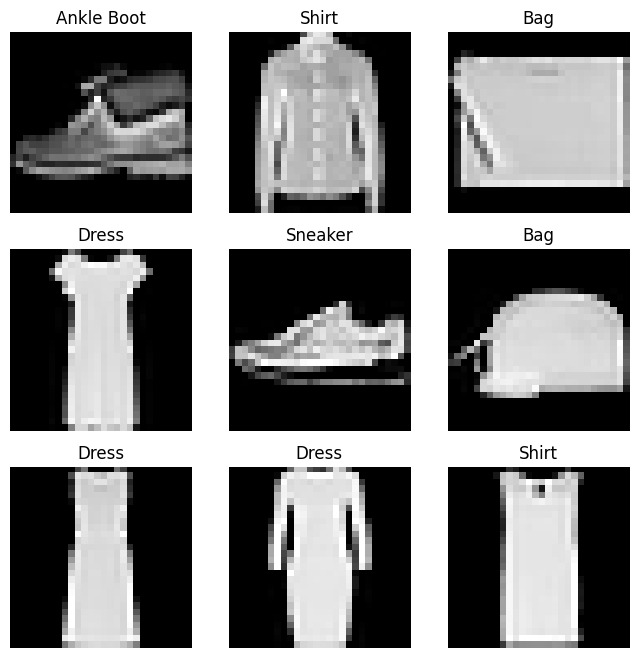

In [27]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[int(sample_idx)]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

## Custom Datasets

A custom Dataset class must implement three functions:
- `__init__`
- `__len__`
- `__getitem__`

In [14]:
from typing import List, Tuple, Any

class CustomDataset(Dataset):
    def __init__(self, features: List[Any], labels: List[Any]):
        self.features = features
        self.labels = labels

    def __len__(self) -> int:
        return len(self.labels)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        data = torch.tensor(self.features[index])
        label = torch.tensor(self.labels[index])
        return data, label

# Example usage
features = [1, 2, 3, 4, 5]
labels = [1, 2, 3, 4, 5]
dataset = CustomDataset(features, labels)
print(dataset[0])  # Output: (tensor(1), tensor(1))
print(len(dataset))  # Output: 5

(tensor(1), tensor(1))
5


The `Dataset` retrieves samples one at a time. `DataLoader` is an iterable that allows typical batching done with deep learning

In [15]:
from torch.utils.data import DataLoader

# Continuing using the FashionMNIST data
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [16]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


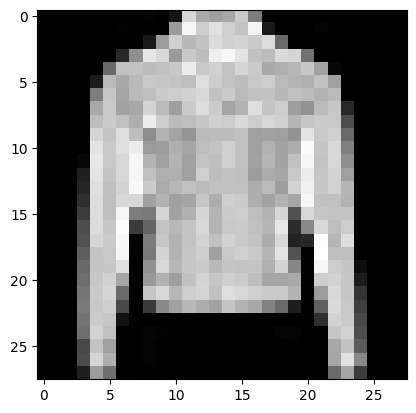

Label: Coat


In [17]:
img = train_features[0].squeeze()  # remove single-dimensional entries from the shape (e.g., [1, 28, 28] -> [28, 28])
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {labels_map[label.item()]}")

# Transforms
- Performing manipulation of the input data to make it suitable for training

In [18]:
# The fashion data has PIL image format as features, and the labels are integers. 

# For training we need the features as normalized tensors, and the labels as one-hot encoded tensors

from torchvision.transforms import ToTensor, Lambda

In [ ]:
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # converts PIL image or NumPy array into a FloatTensor
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)
# torch.zeros(10, dtype=torch.float) creates a tensor of 10 zeros.
# .scatter_(0, torch.tensor(y), value=1) sets the position at index y to 1

In [ ]:
# Example of .scatter_
torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(2), value=1)

tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Build the Neural Network